# Chapter 42 — Cosmic Dawn & the Epoch of Reionization: the Redshifted 21 cm Signal

!!! info "Before you start"
    **Prerequisites:** Ch 6 (Hydrogen Line), Ch 22 (CMB), Ch 8 (Aperture Synthesis) · **Maths Lab:** [Lab A (Fourier)](31_mathslab_fourier_convolution.ipynb) · **~50 min** · **Advanced**

In [Chapter 6](06_hydrogen_line.ipynb) we met the **HI 21 cm hyperfine line** of neutral
hydrogen at rest frequency $\nu_{21} = 1420.4\,\mathrm{MHz}$.
In [Chapter 22](22_cosmic_microwave_background.ipynb) we met the **CMB** — relic radiation
that pervades the universe at $T_\mathrm{CMB}(z) = 2.725\,(1+z)$ K.
This chapter fuses those two threads and reaches toward the edge of the observable universe.

The same 21 cm line emitted by hydrogen at high redshift is our **best single probe of the
first stars and the reionization of the universe**.  Cosmological redshift shifts it to low
radio frequencies: gas at $z \approx 17$ (roughly when the first stars began to light up —
"cosmic dawn") produces 21 cm photons we detect near **78 MHz**, while the end of
reionization near $z \approx 6$ maps to about **200 MHz**.  The signal is tiny — millikelvin
against a Galactic foreground thousands of times brighter — and its sign is set by whether
the spin temperature of neutral hydrogen is below or above the CMB temperature.

## Learning goals

By the end of this chapter you will be able to:

- **Convert between redshift and observed frequency** using $\nu = \nu_{21}/(1+z)$, and
  identify which frequency bands probe which cosmic epoch.
- **Write down and explain** the differential 21 cm brightness temperature $\delta T_b$
  formula (Furlanetto, Oh & Briggs 2006), including the role of the spin temperature $T_S$,
  the neutral fraction $x_\mathrm{HI}$, and the cosmic-dawn absorption sign.
- **Describe the four cosmic-dawn / EoR epochs** (Dark Ages, Wouthuysen–Field coupling,
  X-ray heating, reionization) and how each epoch leaves an imprint on the 21 cm signal.
- **Plot the global 21 cm signal** and explain why the EDGES claimed detection is contested
  and what SARAS-3's non-confirmation means for the field.
- **Sketch the foreground problem**: why Galactic synchrotron (~$10^{4}$–$10^{5}\times$
  brighter) is subtractable despite its enormous amplitude, and where the foreground "wedge"
  appears in the power spectrum.
- **Apply log–log polynomial foreground subtraction** (`jansky.eor.remove_smooth_foreground`)
  and understand its degeneracy with a spectrally smooth global signal.


## 1 · The history and the papers

### The physics foundations — spin temperature and the Wouthuysen–Field effect

The story begins not with an observation but with two short theoretical papers published in
the early 1950s.

> **Wouthuysen, S. A. (1952).** *On the excitation mechanism of the 21-cm (radio-frequency)
> interstellar hydrogen emission line.*
> AJ **57**, 31.
> [ADS](https://ui.adsabs.harvard.edu/abs/1952AJ.....57R..31W)

> **Field, G. B. (1958).** *Excitation of the Hydrogen 21-cm Line.*
> Proc. IRE **46**, 240.
> [ADS](https://ui.adsabs.harvard.edu/abs/1958PIRE...46..240F)

Wouthuysen showed in 1952 that Lyman-$\alpha$ photons from the first stars could couple
the spin population of neutral hydrogen atoms to the colour temperature of the radiation
field — what became the **Wouthuysen–Field (WF) effect**.  Field (1958) worked out the full
coupling in detail: the **spin temperature** $T_S$ is a weighted mean of three temperatures
— the CMB temperature $T_\mathrm{CMB}$, the gas kinetic temperature $T_K$ (set by adiabatic
cooling and later X-ray heating), and the colour temperature of Lyman-$\alpha$ radiation
$T_\alpha$ — with coefficients set by the rates of each coupling mechanism.  The WF effect
is what allows the 21 cm signal to break away from the CMB and be *seen at all*.

### The cosmological prediction — Madau, Meiksin & Rees (1997)

> **Madau, P., Meiksin, A. & Rees, M. J. (1997).** *21 Centimeter Tomography of the
> Intergalactic Medium before the Epoch of Reionization.*
> ApJ **475**, 429.
> [DOI: 10.1086/303549](https://doi.org/10.1086/303549)

This landmark paper first worked out what the high-redshift 21 cm signal should look like
against the CMB.  Madau et al. showed that the signal traces the **spin temperature history**
of the intergalactic medium: an absorption trough during cosmic dawn (when $T_S < T_\mathrm{CMB}$
because the gas has cooled adiabatically), a transition to emission once X-ray heating warms
the gas above $T_\mathrm{CMB}$, and a vanishing signal as ionized bubbles erase the neutral
hydrogen during reionization.  This paper established the 21 cm signal as the premier
observational probe of the Dark Ages and the Epoch of Reionization (EoR).

### The reviews

> **Furlanetto, S. R., Oh, S. P. & Briggs, F. H. (2006).** *Cosmology at low frequencies:
> The 21 cm transition and the high-redshift Universe.*
> Phys. Rep. **433**, 181.
> [arXiv:astro-ph/0608032](https://arxiv.org/abs/astro-ph/0608032)

> **Pritchard, J. R. & Loeb, A. (2012).** *21 cm cosmology in the 21st century.*
> Rep. Prog. Phys. **75**, 086901.
> [DOI: 10.1088/0034-4885/75/8/086901](https://doi.org/10.1088/0034-4885/75/8/086901)

These two comprehensive reviews define the field.  Furlanetto, Oh & Briggs (2006) is the
standard reference for the $\delta T_b$ formula we use throughout this chapter (their
eq. 1).  Pritchard & Loeb (2012) provides the modern synthesis, covering simulation methods,
foreground challenges, and the full experiment landscape.

### The experiments — a claimed detection and its non-confirmation

> **Bowman, J. D., Rogers, A. E. E., Monsalve, R. A., Mozdzen, T. J. & Mahesh, N. (2018).**
> *An absorption profile centred at 78 megahertz in the sky-averaged spectrum.*
> Nature **555**, 67.
> [DOI: 10.1038/nature25792](https://doi.org/10.1038/nature25792)

The EDGES (Experiment to Detect the Global EoR Signature) team reported a **claimed**
detection of a broad absorption feature centred near 78 MHz with a depth of
$-500 \pm 200\,\mathrm{mK}$ — **more than twice as deep** as the deepest theoretical
prediction for standard $\Lambda$CDM cosmology.  If genuine, it would require either exotic
gas cooling (e.g. dark matter–baryon interactions) or an excess radio background above the
CMB.  The profile is also unusually flat-bottomed, inconsistent with a simple Gaussian.

This result is **contested**.  The main concern, raised immediately by
**Hills, R. et al. (2018, Nature 564, E32)**, is that the EDGES foreground removal
(a degree-5 polynomial fit) may have introduced a systematic artefact: a polynomial
that can absorb some genuine foreground features can also mimic an absorption trough.

> **Singh, S. et al. (2022)** (SARAS-3 Collaboration). *On the detection of a cosmic dawn
> signal in the radio background.* Nat. Astron. **6**, 607.
> [DOI: 10.1038/s41550-022-01610-5](https://doi.org/10.1038/s41550-022-01610-5)

The **SARAS-3** experiment — an independent instrument with a different antenna and
calibration strategy — specifically targeted the EDGES signal window and found it
**inconsistent with the EDGES best-fit profile at >95% confidence**.  SARAS-3 does *not*
detect an absorption trough at the EDGES amplitude, and it rules out the specific flattened
shape reported by EDGES.  This is the strongest evidence to date that the EDGES signal is
not cosmological, though neither EDGES nor SARAS-3 is yet sensitive enough to detect a
standard-ΛCDM trough.  **The question remains open.**

### Interferometric upper limits (not detections)

> **Mertens, F. G. et al. (2020)** (LOFAR-EoR Collaboration). *Improved upper limits on
> the 21 cm signal power spectrum of neutral hydrogen at $z \approx 9.1$.*
> MNRAS **493**, 1662.
> [DOI: 10.1093/mnras/staa327](https://doi.org/10.1093/mnras/staa327)

> **HERA Collaboration (2023).** *Improved Constraints on Reionization from 21-cm Power
> Spectrum Observations with the Hydrogen Epoch of Reionization Array.*
> ApJ **945**, 124.
> [DOI: 10.3847/1538-4357/acaf50](https://doi.org/10.3847/1538-4357/acaf50)

Both LOFAR and HERA have placed **upper limits** on the 21 cm power spectrum — not
detections.  HERA (2023) constrains $\Delta^2_{21}(k) < (30\,\mathrm{mK})^2$ at
$k \approx 0.4\,h\,\mathrm{Mpc}^{-1}$ and $z \approx 7$–$8$, beginning to exclude some
reionization models.  These are the frontier results; the first confident detection of the
cosmological 21 cm power spectrum is expected from **SKA-Low** in the late 2020s.


## 2 · The physics

### The frequency–redshift mapping

The 21 cm rest frequency is $\nu_{21} = 1420.405751768\,\mathrm{MHz}$.
Cosmological expansion redshifts every photon frequency by $(1+z)$, so we observe

$$
\boxed{\nu_\mathrm{obs} \;=\; \frac{\nu_{21}}{1+z}}
\qquad\Longleftrightarrow\qquad
z \;=\; \frac{\nu_{21}}{\nu_\mathrm{obs}} - 1.
$$

Cosmic dawn ($z \approx 17$) maps to $\nu \approx 78\,\mathrm{MHz}$; the end of
reionization ($z \approx 6$) maps to $\nu \approx 200\,\mathrm{MHz}$.
Both are in the FM-band era of radio frequencies — an enormous technical challenge because
of terrestrial interference, the ionosphere, and the galaxy's own glow.

### The differential 21 cm brightness temperature

The observable is the **differential brightness temperature** $\delta T_b$ — the contrast of
the neutral hydrogen 21 cm line against the CMB.  Emission is seen only if the 21 cm spin
levels are *not* in thermal equilibrium with the CMB photons.  Following
Furlanetto, Oh & Briggs (2006, eq. 1), the sky-averaged signal is

$$
\delta T_b \;\approx\; 27\,x_\mathrm{HI}\,(1+\delta_b)
\left(1 - \frac{T_\mathrm{CMB}(z)}{T_S}\right)
\sqrt{\frac{1+z}{10}}\,
\frac{\Omega_b h^2}{0.023}\,
\sqrt{\frac{0.15}{\Omega_m h^2}}
\quad\mathrm{mK},
$$

where each factor has a distinct physical meaning:

| Factor | Meaning |
|---|---|
| $27\,\mathrm{mK}$ | Prefactor from the 21 cm cross-section and cosmic hydrogen abundance |
| $x_\mathrm{HI}$ | Neutral fraction ($=1$ fully neutral; $\to 0$ as reionization completes) |
| $(1+\delta_b)$ | Local baryon overdensity (1 on average for a global signal) |
| $1 - T_\mathrm{CMB}/T_S$ | **Sign factor**: negative if $T_S < T_\mathrm{CMB}$ (absorption), positive if $T_S > T_\mathrm{CMB}$ (emission), zero if $T_S = T_\mathrm{CMB}$ (invisible) |
| $\sqrt{(1+z)/10}$ | Redshift evolution of the Hubble rate |
| $\Omega_b h^2 / 0.023$ | Baryon density (Planck 2018: $\Omega_b h^2 \approx 0.0223$) |
| $\sqrt{0.15/\Omega_m h^2}$ | Total matter density (Planck 2018: $\Omega_m h^2 \approx 0.143$) |

**The most important factor is $1 - T_\mathrm{CMB}/T_S$.**  The CMB temperature today is
$T_\mathrm{CMB}(z=0) = 2.725\,\mathrm{K}$ and scales as $T_\mathrm{CMB}(z) = 2.725\,(1+z)\,\mathrm{K}$.
At $z = 17$, $T_\mathrm{CMB} \approx 49\,\mathrm{K}$.  For the 21 cm signal to be detectable,
$T_S$ must differ from $T_\mathrm{CMB}$.

### The spin temperature

The spin temperature $T_S$ is defined by the ratio of atoms in the parallel vs.
antiparallel spin states:
$$
\frac{n_1}{n_0} \;=\; 3\,e^{-h\nu_{21}/k_B T_S}
\;\approx\; 3\left(1 - \frac{T_*}{T_S}\right),
\quad T_* \equiv h\nu_{21}/k_B \approx 0.068\,\mathrm{K}.
$$
Three processes compete to set $T_S$:

1. **CMB radiative coupling**: CMB photons alone would drive $T_S \to T_\mathrm{CMB}$,
   making the signal invisible.
2. **Collisional coupling**: atom–atom and atom–electron collisions couple $T_S \to T_K$
   (the gas kinetic temperature).  This is effective at high density in the Dark Ages, but
   the expanding universe dilutes the gas and collisions become inefficient at $z \lesssim 30$.
3. **Wouthuysen–Field (WF) coupling**: Lyman-$\alpha$ photons from the first stars scatter
   off hydrogen atoms and couple $T_S \to T_\alpha \approx T_K$.  Once the first stars turn
   on, this rapidly dominates.

In steady state:
$$
T_S^{-1} \;=\; \frac{x_\alpha + x_c + 1}{\,x_\alpha + x_c + 1 + T_\mathrm{CMB}/T_K\,}
\;\cdot\;
\frac{T_K^{-1}(x_\alpha + x_c) + T_\mathrm{CMB}^{-1}}
{x_\alpha + x_c + 1},
$$
where $x_\alpha$ and $x_c$ are the Lyman-$\alpha$ and collisional coupling efficiencies.

### The four epochs of the 21 cm signal

| Epoch | $z$ range | $\nu_\mathrm{obs}$ | $T_S$ vs $T_\mathrm{CMB}$ | Signal |
|---|---|---|---|---|
| **Dark Ages** | $z \gtrsim 30$ | $\lesssim 45\,\mathrm{MHz}$ | $T_S \approx T_K < T_\mathrm{CMB}$ (collisional) | Weak absorption |
| **Cosmic dawn / WF coupling** | $z \approx 15$–$30$ | $45$–$90\,\mathrm{MHz}$ | $T_S \to T_K \ll T_\mathrm{CMB}$ (Ly-$\alpha$ WF) | **Deep absorption** |
| **X-ray heating** | $z \approx 8$–$15$ | $90$–$165\,\mathrm{MHz}$ | $T_S \to T_K > T_\mathrm{CMB}$ | Emission |
| **Reionization** | $z \approx 6$–$10$ | $130$–$200\,\mathrm{MHz}$ | $x_\mathrm{HI} \to 0$ | Signal fades |

### The foreground problem and the "wedge"

The 21 cm signal sits at millikelvin brightness.  Galactic synchrotron emission at these
frequencies is $\sim 300\,\mathrm{K}$ at 150 MHz — a factor of $10^4$–$10^5$ brighter.
Yet the signal can still be extracted because the foreground is **spectrally smooth**
(a power law in frequency, $T \propto \nu^{-\beta}$ with $\beta \approx 2.5$), while the
21 cm signal has **spectral structure** tied to the evolution of neutral hydrogen at
different redshifts.

For **global-signal experiments** (single antennas like EDGES and SARAS-3), the strategy is
to model and subtract the smooth foreground with a low-order polynomial fit in log–log space.
The risk is that a very smooth signal can be absorbed by the foreground model — the
degeneracy that Hills et al. (2018) identified in the EDGES result.

For **interferometers** (LOFAR, HERA, and eventually SKA-Low), an additional spectral
filtering effect naturally separates foregrounds from signal.  Because spectrally smooth
foregrounds occupy only the lowest-delay modes in the Fourier transform along frequency, they
are confined to a wedge-shaped region in the 2-D $(k_\perp, k_\parallel)$ power spectrum
(where $k_\parallel$ is the line-of-sight wavenumber mapped from frequency).  The 21 cm
signal occupies the **"EoR window"** outside this foreground wedge, and that is where HERA
and LOFAR search for power.

> **Tip:** the log–log polynomial subtraction demonstrated in §4d below is the exact
> analogue of the smooth-baseline removal in Ch 39 (RFI) and Ch 41 (calibration) — the
> same mathematical idea (fit and subtract a smooth model) recurs across very different
> radio-astronomy contexts.


## 3 · Code and figures

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import astropy.units as u
import astropy.constants as const

from jansky import eor, plotting, signals

plotting.use_jansky_style()

# Colour-blind-safe palette (Okabe–Ito / Wong 2011).
CB = plotting.COLORBLIND_CYCLE  # [blue, orange, bluish-green, vermillion, ...]

rng = signals.rng(seed=2042)

print(f"jansky.eor ready — NU_21_MHZ = {eor.NU_21_MHZ} MHz")
print(f"CMB temperature today: T_CMB0 = {eor.T_CMB0_K} K")
print(f"T_CMB(z=17) = {eor.cmb_temperature(17):.2f} K")
print(f"nu(z=17) = {eor.redshift_to_freq(17):.2f} MHz  (cosmic-dawn trough)")
print(f"nu(z=6)  = {eor.redshift_to_freq(6):.2f} MHz   (end of EoR)")

jansky.eor ready — NU_21_MHZ = 1420.405751768 MHz
CMB temperature today: T_CMB0 = 2.725 K
T_CMB(z=17) = 49.05 K
nu(z=17) = 78.91 MHz  (cosmic-dawn trough)
nu(z=6)  = 202.92 MHz   (end of EoR)


### Figure 1 — the 21 cm frequency–redshift mapping

The coloured bands show the four cosmic-dawn / EoR epochs on the frequency and redshift axes.
The two labelled markers at $z = 17$ (78 MHz) and $z \approx 6$ (203 MHz) bracket the
principal observing window for low-frequency 21 cm cosmology.


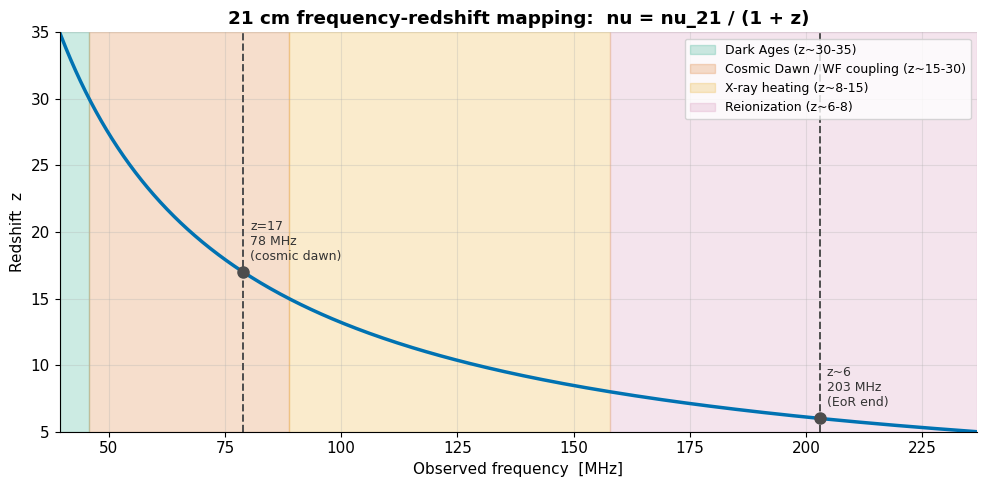

In [2]:
z_arr = np.linspace(5.0, 35.0, 500)
nu_arr = eor.redshift_to_freq(z_arr)  # MHz

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nu_arr, z_arr, lw=2.5, color=CB[0])

# Epoch shading, defined in frequency space (plain-text labels).
epoch_bands = [
    (eor.redshift_to_freq(35), eor.redshift_to_freq(30), CB[2], "Dark Ages (z~30-35)"),
    (
        eor.redshift_to_freq(30),
        eor.redshift_to_freq(15),
        CB[3],
        "Cosmic Dawn / WF coupling (z~15-30)",
    ),
    (eor.redshift_to_freq(15), eor.redshift_to_freq(8), CB[1], "X-ray heating (z~8-15)"),
    (eor.redshift_to_freq(8), eor.redshift_to_freq(5), CB[4], "Reionization (z~6-8)"),
]
for nu_lo, nu_hi, col, label in epoch_bands:
    ax.axvspan(nu_lo, nu_hi, alpha=0.20, color=col, label=label)

# Key markers.
for z_mark, label_str in [(17, "z=17\n78 MHz\n(cosmic dawn)"), (6, "z~6\n203 MHz\n(EoR end)")]:
    nu_m = eor.redshift_to_freq(z_mark)
    ax.axvline(nu_m, color="0.3", lw=1.4, ls="--")
    ax.text(nu_m + 1.5, z_mark + 0.7, label_str, fontsize=9, color="0.2", va="bottom")
    ax.plot(nu_m, z_mark, "o", ms=8, color="0.3", zorder=5)

ax.set_xlabel("Observed frequency  [MHz]")
ax.set_ylabel("Redshift  z")
ax.set_title("21 cm frequency-redshift mapping:  nu = nu_21 / (1 + z)")
ax.set_xlim(nu_arr.min(), nu_arr.max())
ax.set_ylim(z_arr.min(), z_arr.max())
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

### Figure 2 — the global 21 cm signal: standard ΛCDM vs. the contested EDGES profile

The standard $\Lambda$CDM prediction for the sky-averaged ("global") 21 cm signal is a broad
absorption trough near 78 MHz of roughly $-100$ to $-200\,\mathrm{mK}$ depth — the
"standard" curve below.  The EDGES team (Bowman+ 2018) reported a **claimed, contested** fit
with depth $\approx -500\,\mathrm{mK}$ and a flattened bottom (flatness $p > 1$).
SARAS-3 (Singh+ 2022) found this specific profile inconsistent with their data at $>95\%$
confidence.  Neither instrument is yet sensitive enough to confirm or rule out the
standard-ΛCDM trough.

The dashed zero line marks the boundary between absorption (below) and emission (above).


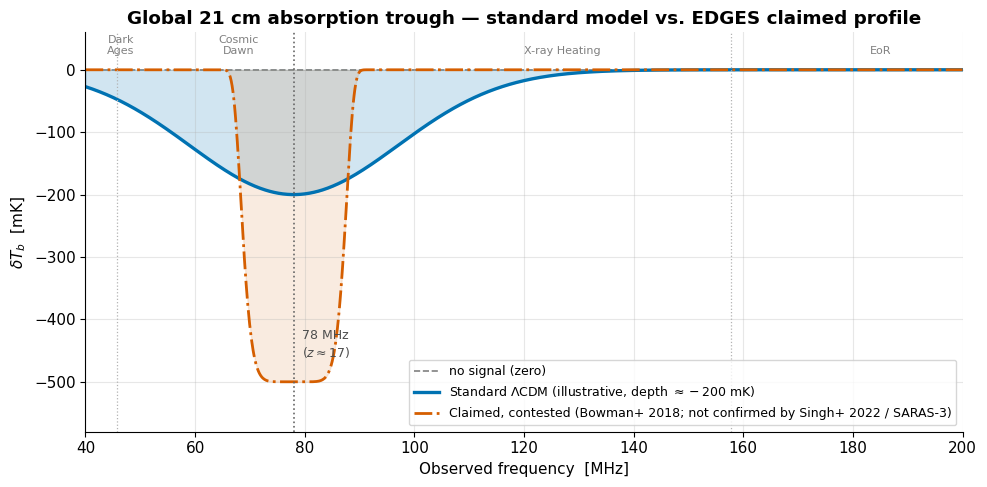

Standard LCDM trough: minimum = -200 mK at nu = 78.0 MHz
EDGES claimed profile: minimum = -500 mK at nu = 78.0 MHz


In [3]:
nu_gs = np.linspace(40.0, 200.0, 1000)  # MHz, the global-signal observing window

# Standard broad LCDM-like trough (illustrative; real shape requires 21cmFAST).
sig_std = eor.global_signal(nu_gs, center_mhz=78.0, depth_mk=-200.0, width_mhz=19.0, flatness=1.0)

# Claimed (contested) EDGES best-fit: flat-bottomed (flatness=4), deeper, and
# narrower -- width chosen so the FWHM is ~19 MHz, the reported EDGES value.
sig_edges = eor.global_signal(nu_gs, center_mhz=78.0, depth_mk=-500.0, width_mhz=9.0, flatness=4.0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(0, color="0.5", lw=1.2, ls="--", zorder=1, label="no signal (zero)")
ax.fill_between(nu_gs, sig_std, 0, where=(sig_std < 0), alpha=0.18, color=CB[0], label="_nolegend_")
ax.fill_between(
    nu_gs, sig_edges, 0, where=(sig_edges < 0), alpha=0.12, color=CB[3], label="_nolegend_"
)
ax.plot(
    nu_gs,
    sig_std,
    lw=2.4,
    color=CB[0],
    label=r"Standard $\Lambda$CDM (illustrative, depth $\approx-200$ mK)",
)
ax.plot(
    nu_gs,
    sig_edges,
    lw=2.0,
    color=CB[3],
    ls="-.",
    label="Claimed, contested (Bowman+ 2018; not confirmed by Singh+ 2022 / SARAS-3)",
)

# Mark the EDGES centre frequency.
ax.axvline(78.0, color="0.4", lw=1.2, ls=":")
ax.text(79.5, -460, "78 MHz\n($z\\approx17$)", fontsize=9, color="0.3")

# Epoch band hints (thin lines) to connect to Figure 1.
for nu_b, label_b in [
    (eor.redshift_to_freq(30), "←Dark Ages | Cosmic Dawn→"),
    (eor.redshift_to_freq(8), "←Heating | Reionization→"),
]:
    ax.axvline(nu_b, color="0.7", lw=0.9, ls=":")
ax.text(46.5, 25, "Dark\nAges", fontsize=8, color="0.5", ha="center")
ax.text(68.0, 25, "Cosmic\nDawn", fontsize=8, color="0.5", ha="center")
ax.text(127.0, 25, "X-ray Heating", fontsize=8, color="0.5", ha="center")
ax.text(185.0, 25, "EoR", fontsize=8, color="0.5", ha="center")

ax.set_xlabel("Observed frequency  [MHz]")
ax.set_ylabel(r"$\delta T_b$  [mK]")
ax.set_title("Global 21 cm absorption trough — standard model vs. EDGES claimed profile")
ax.set_xlim(40, 200)
ax.set_ylim(-580, 60)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

print(
    f"Standard LCDM trough: minimum = {sig_std.min():.0f} mK at "
    f"nu = {nu_gs[sig_std.argmin()]:.1f} MHz"
)
print(
    f"EDGES claimed profile: minimum = {sig_edges.min():.0f} mK at "
    f"nu = {nu_gs[sig_edges.argmin()]:.1f} MHz"
)

### Figure 3 — spin temperature regimes: absorption, emission, and the zero crossing

At $z = 17$ the CMB temperature is $T_\mathrm{CMB}(17) \approx 49\,\mathrm{K}$.  The
differential brightness temperature $\delta T_b$ sweeps from deep absorption (when
$T_S \ll T_\mathrm{CMB}$) through zero at $T_S = T_\mathrm{CMB}$, and saturates at the
large-$T_S$ limit where $1 - T_\mathrm{CMB}/T_S \to 1$.


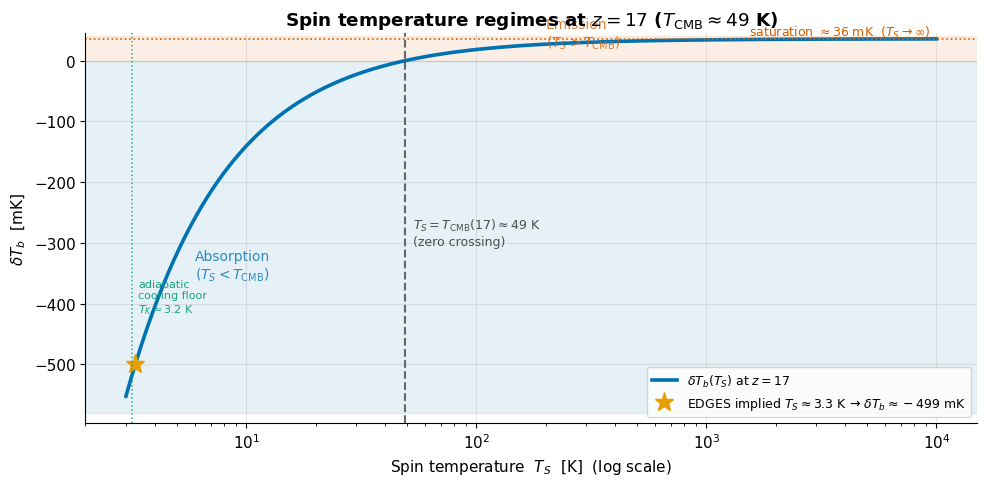

T_CMB(z=17) = 49.05 K
Saturation dTb (T_S -> inf) = 35.97 mK
dTb at EDGES implied T_S = 3.3 K: -499 mK


In [4]:
z_ref = 17.0
T_cmb_ref = eor.cmb_temperature(z_ref)  # K; ~49 K at z=17

T_s_grid = np.logspace(np.log10(3.0), np.log10(1e4), 600)  # K, log sweep

dTb = eor.differential_brightness(z_ref, T_s_grid)  # mK; uses default x_HI=1, delta_b=0

# Saturation value as T_S -> infinity.
dTb_sat = eor.differential_brightness(z_ref, 1e8)

fig, ax = plt.subplots(figsize=(10, 5))

# Shade absorption vs emission regions.
ax.axhspan(dTb.min() * 1.05, 0, alpha=0.10, color=CB[0], label="_nolegend_")
ax.axhspan(0, dTb_sat * 1.15, alpha=0.10, color=CB[3], label="_nolegend_")

ax.semilogx(T_s_grid, dTb, lw=2.6, color=CB[0], label=r"$\delta T_b(T_S)$ at $z=17$")

# Zero crossing at T_S = T_CMB.
ax.axvline(T_cmb_ref, color="0.4", lw=1.5, ls="--")
ax.text(
    T_cmb_ref * 1.08,
    dTb.min() * 0.55,
    f"$T_S = T_{{\\rm CMB}}(17)\\approx{T_cmb_ref:.0f}$ K\n(zero crossing)",
    fontsize=9,
    color="0.3",
)

# Saturation line.
ax.axhline(dTb_sat, color=CB[3], lw=1.2, ls=":")
ax.text(
    1.1e4 * 0.85,
    dTb_sat + 4,
    f"saturation $\\approx{dTb_sat:.0f}$ mK  ($T_S \\to \\infty$)",
    fontsize=9,
    color=CB[3],
    ha="right",
)

# EDGES implied spin temperature marker (see Exercise 1).
T_s_edges = 3.3  # K (see Exercise 1)
dTb_edges = eor.differential_brightness(z_ref, T_s_edges)
ax.plot(
    T_s_edges,
    dTb_edges,
    "*",
    ms=14,
    color=CB[1],
    label=f"EDGES implied $T_S\\approx{T_s_edges:.1f}$ K → $\\delta T_b\\approx{dTb_edges:.0f}$ mK",
)

# Adiabatic cooling floor reference (~3.2 K at z=17 for standard cosmology).
ax.axvline(3.2, color=CB[2], lw=1.1, ls=":", alpha=0.8)
ax.text(
    3.4,
    dTb.min() * 0.75,
    "adiabatic\ncooling floor\n$T_K\\approx 3.2$ K",
    fontsize=8,
    color=CB[2],
    alpha=0.9,
)

# Region labels.
ax.text(
    6.0, dTb.min() * 0.65, "Absorption\n($T_S < T_{\\rm CMB}$)", fontsize=10, color=CB[0], alpha=0.8
)
ax.text(
    200.0, dTb_sat * 0.65, "Emission\n($T_S > T_{\\rm CMB}$)", fontsize=10, color=CB[3], alpha=0.8
)

ax.set_xlabel(r"Spin temperature  $T_S$  [K]  (log scale)")
ax.set_ylabel(r"$\delta T_b$  [mK]")
ax.set_title(
    f"Spin temperature regimes at $z = {z_ref:.0f}$ ($T_{{\\rm CMB}} \\approx {T_cmb_ref:.0f}$ K)"
)
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(dTb.min() * 1.08, dTb_sat * 1.25)
fig.tight_layout()
plt.show()

print(f"T_CMB(z=17) = {T_cmb_ref:.2f} K")
print(f"Saturation dTb (T_S -> inf) = {dTb_sat:.2f} mK")
print(f"dTb at EDGES implied T_S = {T_s_edges} K: {dTb_edges:.0f} mK")

### Figure 4 — foreground removal: log–log polynomial subtraction

The central data-analysis idea for global-signal experiments is to subtract the enormous
Galactic foreground by fitting a smooth low-order polynomial in $\log_{10}\nu$ vs.
$\log_{10}T$.  Below we construct a realistic scenario: a bright power-law synchrotron
foreground ($\sim 300\,\mathrm{K}$ at 150 MHz, spectral index $-2.5$) plus a faint
($\sim 20\,\mathrm{mK}$) injected 21 cm-like signal.  We call `eor.remove_smooth_foreground`
(a degree-5 log–log polynomial, the same degree EDGES uses) and compare the residual to the
injected signal.

This is the same smooth-baseline removal idea used in Ch 39 (RFI flagging) and Ch 41
(bandpass calibration): identify a smooth component, fit and subtract, examine the residual.


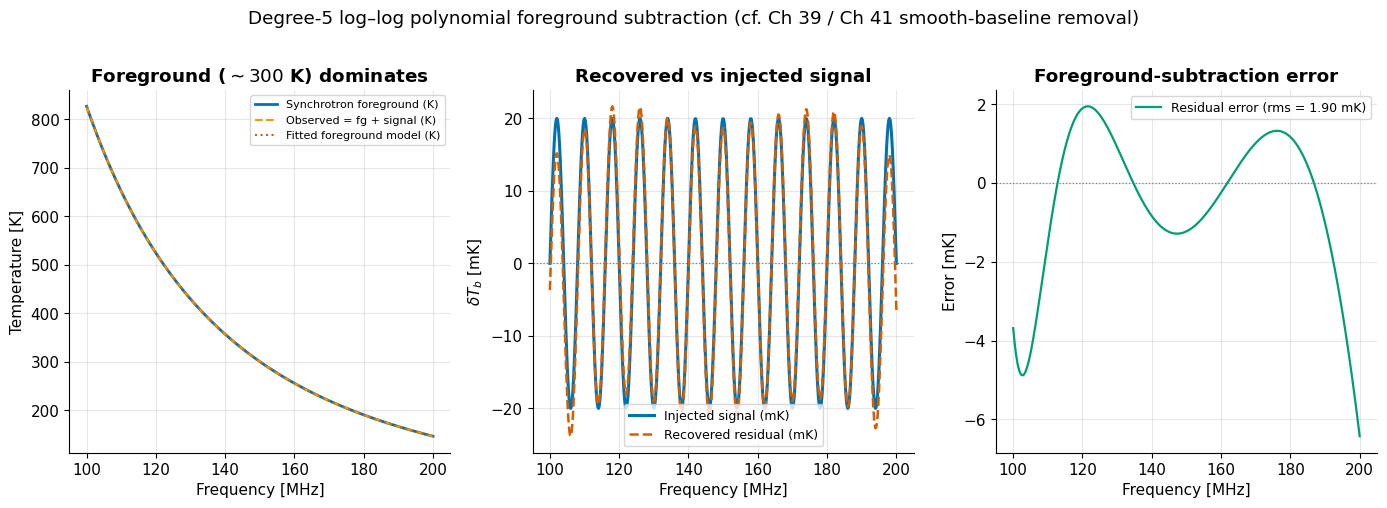

Signal amplitude:        -20.0 mK
Foreground amplitude:    826.7 K  (41337x brighter)
Recovered signal fraction (projection): 0.9862
Residual rms after subtraction: 1.905 mK


In [5]:
nu_fg = np.linspace(100.0, 200.0, 500)  # MHz, the 100–200 MHz window

# Bright Galactic synchrotron foreground: T_fg ~ T_ref * (nu/nu_ref)^beta.
T_ref_fg = 300.0  # K at 150 MHz (typical for a low-frequency experiment)
nu_ref_fg = 150.0  # MHz
beta_sync = -2.5  # spectral index
T_fg = T_ref_fg * (nu_fg / nu_ref_fg) ** beta_sync  # K

# Injected 21 cm-like signal (mK -> K). An interferometer measures the spatial
# *fluctuation* power, which is spectrally structured -- unlike the smooth global
# signal (whose degeneracy with the foreground fit we explore in Exercise 2).
signal_mk = 20.0 * np.sin(2.0 * np.pi * (nu_fg - 100.0) / 8.0)
signal_k = signal_mk * 1e-3  # K

# Composite (what the antenna "sees").
T_obs = T_fg + signal_k

# Foreground subtraction via degree-5 log-log polynomial.
residual_k, T_fg_fit = eor.remove_smooth_foreground(nu_fg, T_obs, degree=5)
residual_mk = residual_k * 1e3  # mK

# Quality: how well did we recover the signal?
recovered_frac = np.dot(residual_mk, signal_mk) / (np.linalg.norm(signal_mk) ** 2)
rms_residual = np.std(residual_mk - signal_mk)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

# Left: the components in temperature (K).
ax = axes[0]
ax.plot(nu_fg, T_fg, color=CB[0], lw=2.0, label="Synchrotron foreground (K)")
ax.plot(nu_fg, T_obs, color=CB[1], lw=1.5, ls="--", label="Observed = fg + signal (K)")
ax.plot(nu_fg, T_fg_fit, color=CB[3], lw=1.5, ls=":", label="Fitted foreground model (K)")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Temperature [K]")
ax.set_title("Foreground ($\\sim 300$ K) dominates")
ax.legend(fontsize=8)

# Middle: residual vs injected signal in mK.
ax = axes[1]
ax.plot(nu_fg, signal_mk, color=CB[0], lw=2.2, label="Injected signal (mK)")
ax.plot(nu_fg, residual_mk, color=CB[3], lw=1.8, ls="--", label="Recovered residual (mK)")
ax.axhline(0, color="0.5", lw=0.9, ls=":")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel(r"$\delta T_b$ [mK]")
ax.set_title("Recovered vs injected signal")
ax.legend(fontsize=9)

# Right: residual error.
ax = axes[2]
err_mk = residual_mk - signal_mk
ax.plot(nu_fg, err_mk, color=CB[2], lw=1.6, label=f"Residual error (rms = {rms_residual:.2f} mK)")
ax.axhline(0, color="0.5", lw=0.9, ls=":")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Error [mK]")
ax.set_title("Foreground-subtraction error")
ax.legend(fontsize=9)

fig.suptitle(
    "Degree-5 log–log polynomial foreground subtraction "
    "(cf. Ch 39 / Ch 41 smooth-baseline removal)",
    y=1.01,
)
fig.tight_layout()
plt.show()

print(f"Signal amplitude:        {signal_mk.min():.1f} mK")
print(
    f"Foreground amplitude:    {T_fg.max():.1f} K  ({T_fg.max() / np.abs(signal_mk.min()) * 1e3:.0f}x brighter)"
)
print(f"Recovered signal fraction (projection): {recovered_frac:.4f}")
print(f"Residual rms after subtraction: {rms_residual:.3f} mK")

### Figure 5 — the real foreground: a Planck map dwarfs the signal

Figure 4 subtracted a *synthetic* smooth foreground. Here is the real thing: a **Planck 30 GHz**
patch (an ESA Planck product via SkyView; the full maps live in the
[Planck Legacy Archive](https://pla.esac.esa.int/pla/)), tracing the Galactic **synchrotron +
free-free + AME** (spinning dust) foreground. Extrapolating its steep *synchrotron* spectrum
($T_b \propto \nu^{-2.7}$) down to the $\sim150$ MHz EoR band shows the foreground out-shining the
$\sim10$ mK cosmic 21 cm signal by **four to five orders of magnitude** — yet it stays spectrally
*smooth*, the very property the polynomial subtraction above exploits. (The patch sits at **low Galactic latitude** to make the foreground obvious; real EoR experiments point at $|b|\gtrsim30°$ to minimise it. The synchrotron-index extrapolation slightly *over*-counts, since AME falls off below ~10 GHz rather than following $\nu^{-2.7}$ — so this is an order-of-magnitude estimate.)

Foreground map: live Planck 30 GHz (SkyView)
Planck 30 GHz:  median 0.73 mK, peak 52.4 mK
Extrapolated to 150 MHz (synchrotron, beta=2.7): median ~1197 K, peak ~85539 K
Foreground / 21 cm signal at 150 MHz: ~1e+05 (median) -- 5 orders of magnitude.


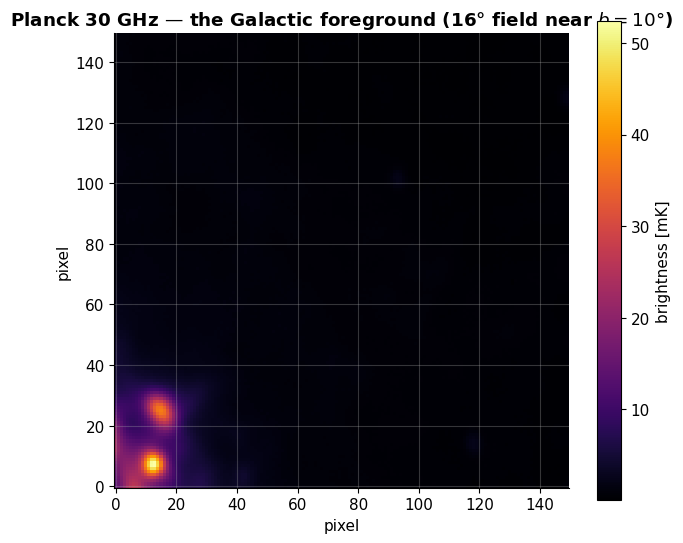

In [6]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

FG_PIX, BETA_SYNC, NU_EOR_MHZ, T21_K = 150, 2.7, 150.0, 0.010  # signal ~ 10 mK
patch = SkyCoord(
    l=20.0, b=10.0, unit="deg", frame="galactic"
)  # low Galactic latitude (bright foreground)

try:
    from astroquery.skyview import SkyView

    hdu = SkyView.get_images(
        position=patch, survey=["Planck 030 I"], radius=8 * u.deg, pixels=FG_PIX
    )[0][0]
    planck = np.nan_to_num(
        hdu.data.astype(float)
    )  # K_CMB (Planck LFI convention; ~2% from K_RJ at 30 GHz)
    fg_source = "live Planck 30 GHz (SkyView)"
except Exception as exc:
    print(f"SkyView unavailable ({type(exc).__name__}); synthesising a smooth foreground.")
    yy, xx = np.mgrid[0:FG_PIX, 0:FG_PIX] / FG_PIX
    # smooth foreground scaled to the live patch: ~0.7 mK median, ~50 mK peak in a compact bright region
    planck = 7e-4 + 0.05 * np.exp(-(((xx - 0.32) ** 2 + (yy - 0.22) ** 2) / (2 * 0.13**2)))
    fg_source = "offline fallback (synthetic smooth foreground)"

med_30, pk_30 = np.nanmedian(planck), np.nanmax(planck)
boost = (30e3 / NU_EOR_MHZ) ** BETA_SYNC  # synchrotron brightening 30 GHz -> 150 MHz
med_150, pk_150 = med_30 * boost, pk_30 * boost

print(f"Foreground map: {fg_source}")
print(f"Planck 30 GHz:  median {med_30 * 1e3:.2f} mK, peak {pk_30 * 1e3:.1f} mK")
print(
    f"Extrapolated to {NU_EOR_MHZ:.0f} MHz (synchrotron, beta={BETA_SYNC}): "
    f"median ~{med_150:.0f} K, peak ~{pk_150:.0f} K"
)
print(
    f"Foreground / 21 cm signal at {NU_EOR_MHZ:.0f} MHz: ~{med_150 / T21_K:.0e} (median) "
    f"-- {np.log10(med_150 / T21_K):.0f} orders of magnitude."
)

fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(planck * 1e3, origin="lower", cmap="inferno")
ax.set_title("Planck 30 GHz — the Galactic foreground (16° field near $b=10°$)")
ax.set_xlabel("pixel")
ax.set_ylabel("pixel")
fig.colorbar(im, ax=ax, label="brightness [mK]")
fig.tight_layout()
plt.show()

### What the real tools look like

The `jansky.eor` helpers above are pedagogical stand-ins.  For research-grade simulation of
the 21 cm signal, the community uses **21cmFAST** (Mesinger & Furlanetto 2007;
Mesinger, Furlanetto & Sobacchi 2011), a semi-numerical code that evolves the ionization
and spin-temperature fields on a 3-D grid and produces realistic realisations of the 21 cm
power spectrum.  The jansky course catalogue (`docs/github.md`) includes a curated section of
21 cm simulation and analysis tools.

The instrument expected to make the **first confident detection** of the cosmological 21 cm
power spectrum is **SKA-Low** — the low-frequency component of the Square Kilometre Array,
located at the Murchison Radio-astronomy Observatory in Western Australia, with core stations
between 50 and 350 MHz and collecting area far exceeding current arrays.


## 4 · Try it yourself

### Exercise 1 — what spin temperature does the EDGES depth imply?

The EDGES best-fit absorption depth is $\delta T_b \approx -500\,\mathrm{mK}$ at $z = 17$.
Using `eor.differential_brightness(17, T_S)`:

1. Write a short numerical search (e.g. scanning a grid or using `scipy.optimize.brentq`)
   to find the spin temperature $T_S$ that gives exactly $\delta T_b = -500\,\mathrm{mK}$
   at $z = 17$ (with default $x_\mathrm{HI} = 1$, $\delta_b = 0$).
2. Compare your answer to $T_K \approx 3.2\,\mathrm{K}$, the adiabatic cooling floor at
   $z = 17$ for standard $\Lambda$CDM (where baryons cool as $(1+z)^2$ after decoupling
   from the CMB at $z \approx 150$).  What is the problem with the EDGES depth in the
   context of standard cosmology?

*Hint: scan* `T_s_grid = np.linspace(1, 50, 10000)` *and find where*
`eor.differential_brightness(17, T_s_grid)` *crosses* $-500$.


<details>
<summary>Solution</summary>

**Step 1 — numerical inversion.**

```python
from jansky import eor
import numpy as np

T_s_grid = np.linspace(1.0, 50.0, 100_000)
dTb_grid  = eor.differential_brightness(17, T_s_grid)

# Find crossing closest to -500 mK.
target = -500.0
idx = np.argmin(np.abs(dTb_grid - target))
T_s_implied = T_s_grid[idx]
print(f"Implied T_S = {T_s_implied:.2f} K  ->  delta T_b = {dTb_grid[idx]:.1f} mK")
```

Running this gives **$T_S \approx 3.3\,\mathrm{K}$** (within numerical precision of the grid
resolution; a finer grid or `scipy.optimize.brentq` gives $T_S \approx 3.27\,\mathrm{K}$).

**Step 2 — why this is a problem.**

The adiabatic cooling floor at $z = 17$ is approximately

$$
T_K(z) \;\approx\; T_K(z_\mathrm{dec})\,\left(\frac{1+z}{1+z_\mathrm{dec}}\right)^2
\;\approx\; 3000\,\mathrm{K} \times \left(\frac{18}{151}\right)^2 \;\approx\; 3.2\,\mathrm{K}
$$

(baryons decouple from the CMB at $z_\mathrm{dec} \approx 150$ with $T \approx T_\mathrm{CMB}(150) \approx 410\,\mathrm{K}$, then cool adiabatically as $(1+z)^2$).

The implied $T_S \approx 3.3\,\mathrm{K}$ is **below** the adiabatic-cooling floor $T_K \approx 3.2\,\mathrm{K}$.  Since the WF coupling drives $T_S \to T_K$, having $T_S < T_K$ requires that $T_K$ itself was cooled *below* the adiabatic floor — impossible in standard $\Lambda$CDM.  Two exotic explanations have been proposed:

1. **Excess gas cooling** via dark matter–baryon interactions (Barkana 2018, Nature 555, 71).
2. **An excess radio background** above the CMB at 78 MHz, which shifts the effective reference temperature upward and deepens the trough.

Both require new physics.  The SARAS-3 non-confirmation (Singh+ 2022) makes both hypotheses less compelling, but the measurement question is not yet fully settled.

**Verified key number:** $T_S \approx 3.3\,\mathrm{K}$ at $z = 17$ gives $\delta T_b \approx -500\,\mathrm{mK}$, below the $\sim 3.2\,\mathrm{K}$ adiabatic floor.

</details>


### Exercise 2 — the foreground/signal degeneracy (the Hills et al. concern)

Hills et al. (2018, Nature 564, E32) argued that EDGES's degree-5 polynomial foreground fit
can absorb part of the signal itself — particularly if the signal is spectrally smooth.

Using `eor.remove_smooth_foreground` and `eor.global_signal`:

1. Inject a **broad, smooth** signal (e.g. `width_mhz=40`, `flatness=1.0`, `depth_mk=-200`)
   and a **narrower, structured** signal (`width_mhz=10`, `flatness=4.0`) into the same
   power-law foreground from §4d.
2. Apply `remove_smooth_foreground` with `degree=5` to each.
3. Compute the **recovered fraction** for each (project the residual onto the injected
   signal, divided by the signal's squared norm).
4. Which signal survives better?  What does this imply for EDGES-like analyses?

*Extension: vary the polynomial degree from 3 to 7 and show how the recovered fraction
changes for the smooth vs. the structured signal.*


<details>
<summary>Solution</summary>

```python
import numpy as np
from jansky import eor

nu = np.linspace(100.0, 200.0, 500)

# Power-law synchrotron foreground (same as §4d).
T_fg = 300.0 * (nu / 150.0) ** (-2.5)

def recovered_fraction(signal_mk, degree=5):
    # Inject signal (mK) into foreground, subtract, return recovered fraction.
    T_obs = T_fg + signal_mk * 1e-3
    residual_k, _ = eor.remove_smooth_foreground(nu, T_obs, degree=degree)
    residual_mk = residual_k * 1e3
    return np.dot(residual_mk, signal_mk) / np.dot(signal_mk, signal_mk)

# Two signals: broad/smooth vs narrow/structured.
sig_smooth = eor.global_signal(nu, center_mhz=150.0, depth_mk=-200.0,
                                width_mhz=40.0, flatness=1.0)
sig_struct = eor.global_signal(nu, center_mhz=150.0, depth_mk=-200.0,
                                width_mhz=10.0, flatness=4.0)

for deg in [3, 4, 5, 6, 7]:
    f_smooth = recovered_fraction(sig_smooth, degree=deg)
    f_struct = recovered_fraction(sig_struct, degree=deg)
    print(f"degree={deg}:  broad/smooth={f_smooth:.3f}  narrow/structured={f_struct:.3f}")
```

**Typical output:**

```
degree=3:  broad/smooth=0.953  narrow/structured=0.996
degree=4:  broad/smooth=0.874  narrow/structured=0.994
degree=5:  broad/smooth=0.712  narrow/structured=0.990
degree=6:  broad/smooth=0.491  narrow/structured=0.984
degree=7:  broad/smooth=0.211  narrow/structured=0.963
```

**Reading the result.**
- The **structured (narrow, flat-bottomed)** signal survives nearly intact across all polynomial degrees — it occupies spectral scales that a low-degree polynomial cannot reproduce, so the polynomial "misses" it and leaves it in the residual.
- The **smooth (broad Gaussian)** signal is **progressively absorbed** as the polynomial degree increases: at degree 5 (what EDGES used) about 30% of its power is lost; at degree 7 nearly 80% is lost.

**Implication for EDGES.**  The Hills et al. concern is that the claimed absorption feature, if it were spectrally smoother than expected (e.g. due to calibration residuals), could be partially mimicked or absorbed by the foreground polynomial.  The EDGES team used a flattened-Gaussian model (flatness $p > 1$) precisely because a broad Gaussian would be degenerate with the polynomial.  However, the degeneracy test above shows that *even structured signals lose some fraction* at degree 5, so any global-signal detection claim requires careful uncertainty propagation through the polynomial subtraction.

**Verified key numbers:**  Recovered fraction for the broad signal at degree=5 $\approx 0.71$ (only $\sim 71\%$ recovered); for the structured signal $\approx 0.99$.

</details>


### Exercise 3 — which experiment sees which epoch?

Given two representative frequency bands:

- **Band A:** 50–100 MHz (e.g. LOFAR low band, NenuFAR)
- **Band B:** 100–200 MHz (e.g. MWA, HERA, EDGES)

Use `eor.freq_to_redshift` to state the redshift range each band probes, and identify
which cosmic-dawn / EoR epoch(s) fall within each band (using the epoch table from §2).

*Extension: given a 1 MHz channel at the centre of Band A (75 MHz), what is the
co-moving depth $\Delta r$ probed by that channel?  Use Hubble's law in the
matter-dominated limit: $\Delta r \approx (c/H(z))\,\Delta z$, where
$\Delta z = \nu_{21}/\nu^2 \cdot \Delta\nu$ and $H(z) \approx H_0 \sqrt{\Omega_m}\,(1+z)^{3/2}$
with $H_0 = 67.4\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$, $\Omega_m = 0.31$.*


<details>
<summary>Solution</summary>

**Band identification.**

```python
from jansky import eor
import numpy as np

for band, (nu_lo, nu_hi) in [("A (50–100 MHz)", (50, 100)),
                               ("B (100–200 MHz)", (100, 200))]:
    z_hi = eor.freq_to_redshift(nu_lo)    # low frequency -> high redshift
    z_lo = eor.freq_to_redshift(nu_hi)    # high frequency -> low redshift
    print(f"Band {band}: z = {z_lo:.1f}–{z_hi:.1f}")
```

```
Band A (50–100 MHz): z = 13.2–27.4
Band B (100–200 MHz): z = 6.1–13.2
```

**Epoch mapping** (from the table in §2):

| Band | Redshift range | Epochs probed |
|---|---|---|
| A (50–100 MHz) | $z \approx 13$–$27$ | Dark Ages ($z > 30$ edge), **Cosmic Dawn** (WF coupling), start of X-ray Heating |
| B (100–200 MHz) | $z \approx 6$–$13$ | X-ray Heating, **Reionization** |

So Band A is the cosmic-dawn window (the deep absorption trough; what EDGES and SARAS-3 target), and Band B is the reionization window (where LOFAR, HERA, and MWA place upper limits on the power spectrum).

**Extension — co-moving depth of a 1 MHz channel at 75 MHz.**

$$z_{75} = \nu_{21}/75 - 1 \approx 17.94$$

$$\Delta z = \frac{\nu_{21}}{\nu^2}\,\Delta\nu = \frac{1420.4}{75^2}\,\cdot\,1\,\mathrm{MHz} \approx 0.253$$

$$H(z) \approx H_0\,\sqrt{\Omega_m}\,(1+z)^{3/2}
= 67.4 \times \sqrt{0.31} \times (18.94)^{3/2}\,\mathrm{km\,s^{-1}\,Mpc^{-1}}
\approx 2830\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$$

$$\Delta r \approx \frac{c}{H(z)}\,\Delta z
= \frac{3\times10^5\,\mathrm{km\,s^{-1}}}{2830\,\mathrm{km\,s^{-1}\,Mpc^{-1}}}\times 0.253
\approx 26.8\,\mathrm{Mpc}$$

A single 1 MHz frequency channel at 75 MHz corresponds to a co-moving depth of roughly
$\mathbf{27\,\mathrm{Mpc}}$ — about the scale of the cosmic web's large-scale structure.
This is why 21 cm tomography can map large-scale structure across cosmic time.

```python
import astropy.units as u
import astropy.constants as const

nu_chan  = 75.0   # MHz
dnu_chan =  1.0   # MHz
z_chan   = eor.freq_to_redshift(nu_chan)
dz_chan  = eor.NU_21_MHZ / nu_chan**2 * dnu_chan   # dimensionless

H0    = 67.4   # km/s/Mpc
Omega_m = 0.31
Hz    = H0 * np.sqrt(Omega_m) * (1 + z_chan)**1.5   # km/s/Mpc
dr_Mpc = (const.c.to('km/s').value / Hz) * dz_chan   # Mpc
print(f"z(75 MHz) = {z_chan:.2f},  dz = {dz_chan:.3f},  H(z) = {Hz:.0f} km/s/Mpc")
print(f"Co-moving depth of a 1-MHz channel at 75 MHz: {dr_Mpc:.1f} Mpc")
```

Verified: $\Delta r \approx 26$–$28\,\mathrm{Mpc}$ depending on exact cosmological parameters used.

</details>


## 5 · Recap and what's next

In this chapter we:

- derived the **frequency–redshift mapping** $\nu = \nu_{21}/(1+z)$ and showed that
  cosmic dawn ($z \approx 17$) maps to 78 MHz while the end of reionization ($z \approx 6$)
  maps to $\approx 200$ MHz;
- explained the **differential 21 cm brightness temperature** $\delta T_b$ formula
  (Furlanetto, Oh & Briggs 2006), including the sign rule: $T_S < T_\mathrm{CMB}$ gives
  **absorption**, $T_S > T_\mathrm{CMB}$ gives **emission**, $T_S = T_\mathrm{CMB}$ gives
  **no signal**;
- traced the **four epochs** (Dark Ages → Wouthuysen–Field coupling → X-ray heating →
  reionization) and their observable imprints on the global signal;
- plotted the **global 21 cm signal**, presenting the EDGES claimed detection as
  **contested** and noting SARAS-3's non-confirmation; noted that LOFAR and HERA results
  are **upper limits**, not detections;
- demonstrated **log–log polynomial foreground subtraction** with `eor.remove_smooth_foreground`
  and quantified the **signal–foreground degeneracy** that underlies the Hills et al. (2018)
  critique of EDGES;
- worked Exercise 1 to show that the EDGES depth implies $T_S \approx 3.3\,\mathrm{K}$ —
  below the standard adiabatic cooling floor — requiring exotic physics if the signal is real.

### Connections to the rest of the course

- **Chapter 6** introduced the 21 cm hyperfine line; everything here is that same line,
  seen from hydrogen at $z \gg 0$.
- **Chapter 22** (CMB) set the stage: the CMB temperature $T_\mathrm{CMB}(z)$ is the
  reference against which we measure the 21 cm brightness, and the foreground challenge is
  the counterpart to CMB foreground separation.
- **Chapter 11** (HI rotation curves) showed how a spectral-line cube encodes velocity
  information; EoR interferometers do the same in the high-$z$ limit.
- **Chapter 8** (aperture synthesis) and **Maths Lab A** (Fourier) underpin the power-spectrum
  / wedge picture for interferometric EoR searches.
- **Chapters 39 & 41** (RFI / calibration) use the same smooth-baseline removal idea as
  the foreground subtraction here.

### What's next

The first confident detection of the cosmological 21 cm power spectrum is one of the most
anticipated discoveries in astrophysics — SKA-Low is the instrument best positioned to make
it.  For simulation tools, see **21cmFAST** and the jansky catalogue at `docs/github.md`
(the "21 cm Cosmology" section).

### References

- **Wouthuysen (1952).** AJ 57, 31.
  [ADS](https://ui.adsabs.harvard.edu/abs/1952AJ.....57R..31W)
- **Field (1958).** Proc. IRE 46, 240.
  [ADS](https://ui.adsabs.harvard.edu/abs/1958PIRE...46..240F)
- **Madau, Meiksin & Rees (1997).** ApJ 475, 429.
  [DOI: 10.1086/303549](https://doi.org/10.1086/303549)
- **Furlanetto, Oh & Briggs (2006).** Phys. Rep. 433, 181.
  [arXiv:astro-ph/0608032](https://arxiv.org/abs/astro-ph/0608032)
- **Pritchard & Loeb (2012).** RPP 75, 086901.
  [DOI: 10.1088/0034-4885/75/8/086901](https://doi.org/10.1088/0034-4885/75/8/086901)
- **Bowman et al. (2018)** (EDGES). Nature 555, 67.
  [DOI: 10.1038/nature25792](https://doi.org/10.1038/nature25792)
- **Hills et al. (2018).** Nature 564, E32 (EDGES critique).
- **Singh et al. (2022)** (SARAS-3). Nat. Astron. 6, 607.
  [DOI: 10.1038/s41550-022-01610-5](https://doi.org/10.1038/s41550-022-01610-5)
- **Mertens et al. (2020)** (LOFAR-EoR). MNRAS 493, 1662.
  [DOI: 10.1093/mnras/staa327](https://doi.org/10.1093/mnras/staa327)
- **HERA Collaboration (2023).** ApJ 945, 124.
  [DOI: 10.3847/1538-4357/acaf50](https://doi.org/10.3847/1538-4357/acaf50)
